<a href="https://colab.research.google.com/github/banul25/EDA-project/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT NAME**   : Aerial Object Classification & Detection



PROJECT SUMMARY:

GITHUB LINK

In [ ]:
ME

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/classification_dataset')

['train', 'valid', 'test']

In [ ]:
train_dir ='/content/drive/MyDrive/classification_dataset/train'
valid_dir = '/content/drive/MyDrive/classification_dataset/valid'
test_dir = '/content/drive/MyDrive/classification_dataset/test'

### Inspecting Dataset Structure and Class Counts

In [ ]:
def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
    return class_counts

print("Training dataset class counts:")
train_counts = count_images_per_class(train_dir)
print(train_counts)

print("\nValidation dataset class counts:")
valid_counts = count_images_per_class(valid_dir)
print(valid_counts)

print("\nTest dataset class counts:")
test_counts = count_images_per_class(test_dir)
print(test_counts)

Training dataset class counts:
{'drone': 1248, 'bird': 1414}

Validation dataset class counts:
{'bird': 217, 'drone': 225}

Test dataset class counts:
{'bird': 121, 'drone': 94}


# visualize imbalance

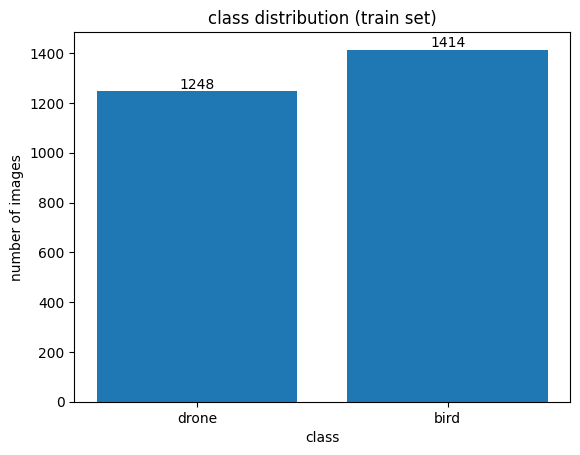

In [ ]:
labels = list(train_counts.keys())
values = list(train_counts.values())
plt.bar(labels,values)
plt.title("class distribution (train set)")
plt.xlabel("class")
plt.ylabel("number of images")
for i, v in enumerate(values):
        plt.text(i, v + 10, str(v), ha='center')
plt.show()

bar chart shows
* bird slightly higher than drone
* slight class imbalance(no need to balance becouse diffrence is very small)

we only check imbalance on train  because
* model learns patterns from training data
* if train data is imbalanced ---model becomes biased


# 2. Data Preprocessing


**Normalize pixel values to [0, 1]**


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


devides every pixel by 255



# **Resize images to a fixed size (224×224 for classification)**

In [ ]:
train_data = train_datagen.flow_from_directory(train_dir,target_size=(224,224),batch_size=32,class_mode='binary')
valid_data = valid_datagen.flow_from_directory(valid_dir, target_size=(224,224),batch_size=32,class_mode='binary')
test_data = test_datagen.flow_from_directory(test_dir, target_size=(224,224),batch_size=32,class_mode='binary')
images, label = next(train_data)
print(images.shape)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
(32, 224, 224, 3)


In [ ]:
#to verify normalization
images, labels = next(train_data)
print("Min pixel value:", images.min())
print("Max pixel value:", images.max())
print()

Min pixel value: 0.0
Max pixel value: 1.0



pixel values originally range from 0 to 255. we normalized them to the range [0,1] using rescaling (1./255),which helps in improving training stability,convergence speed and overall model performance.

images in the dataset have varying sizes,so they were resized to fixe dimention of 224*224 using the target_size parameter. this ensures uniform input to the neural network and compatiblity with standard pre-trained models.

# Visualize sample images

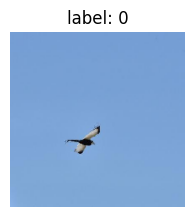

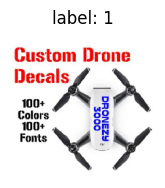

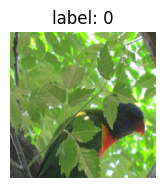

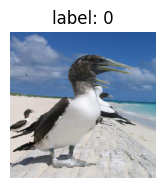

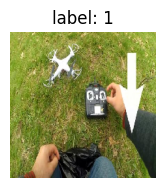

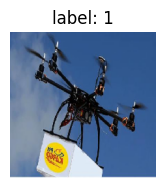

In [ ]:
images, labels = next(train_data)
plt.figure(figsize=(10,5))
for i in range(6):
  plt.subplot(2, 3, i+1)
  plt.imshow(images[i])
  plt.title("label: " +str(int(labels[i])))
  plt.axis('off')
  plt.show()

next(train_data)----featches one batch of images

plt.subplot(2,3,i+1)------creates grid 2row*3columns(total 6 images displayed)

plt.imshow(image[i])-------dispalys the image

label[i]-----shows class : 0-----bird, 1----drone

# 3. Data Augmentation


data augmentation techniues such as rotation,flipping,zooming,brightness adjustment and shifting were applied to artificialy increases dataset diversity and reduce overfitting

# 1.rotation

In [ ]:
rotation_range=30

# 2. flipping

In [ ]:
horizontal_flip=True

# 3. zoom

In [ ]:
zoom_range=0.2

# 4. Brightness

In [ ]:
brightness_range=(0.8,1.2)

## 5.cropping

In [ ]:
width_shift_range=0.1
height_shift_range=0.1

# visualize augmented image

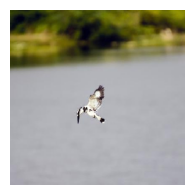

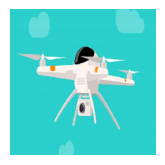

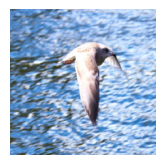

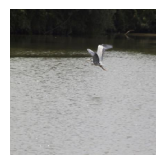

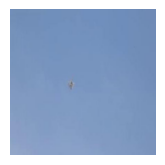

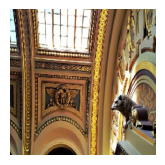

In [ ]:
images , label =next(train_data)
plt.figure(figsize=(10,5))
for i in range(6):
  plt.subplot(2, 3, i+1)
  plt.imshow(images[i])
  plt.axis('off')
  plt.show()

## Model Building (Classification) - Custom CNN

model building -1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Flatten, Dense,Dropout, BatchNormalization
model_custom = Sequential()
#  1st convolution block
model_custom.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model_custom.add(BatchNormalization())
model_custom.add(MaxPooling2D(2,2))
# 2nd convolution block
model_custom.add(Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)))
model_custom.add(BatchNormalization())
model_custom.add(MaxPooling2D(2,2))
# 3rd convolution block
model_custom.add(Conv2D(128, (3,3), activation='relu', input_shape=(224,224,3)))
model_custom.add(BatchNormalization())
model_custom.add(MaxPooling2D(2,2))
#flatten layer
model_custom.add(Flatten())
# fully connected layers
model_custom.add(Dense(128, activation='relu'))
model_custom.add(Dropout(0.5))
#output layer
model_custom.add(Dense(1, activation='sigmoid')) #binarry classification
#compile model
model_custom.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
model_custom.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

# MODEL TRAINING

*1. Import Libraries*

In [ ]:
# import metrics and callbacks (define callbacks)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall


2.Compile Model

In [ ]:
model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

3.Define Callbacks

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("cnn_best_model.keras",monitor='val_loss',save_best_only=True)

earlystopping:--stops training when model stops improving and prevents overfitting
modelcheckpoint:--saves best model

4. TRAIN MODEL

In [ ]:

import time
start = time.time()
history_custom = model_custom.fit(train_data, validation_data=valid_data,epochs=5, callbacks=[early_stop, checkpoint])
end = time.time()
time_cnn = end - start
print("Custom CNN training time:", time_cnn)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 693s 8s/step - accuracy: 0.6957 - loss: 4.9211 - precision: 0.6703 - recall: 0.6907 - val_accuracy: 0.5045 - val_loss: 4.7382 - val_precision: 0.8750 - val_recall: 0.0311
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 507s 6s/step - accuracy: 0.7340 - loss: 1.0344 - precision: 0.7273 - recall: 0.6923 - val_accuracy: 0.6176 - val_loss: 1.2905 - val_precision: 0.9828 - val_recall: 0.2533
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 500s 6s/step - accuracy: 0.7611 - loss: 0.7437 - precision: 0.7909 - recall: 0.6667 - val_accuracy: 0.6787 - val_loss: 1.2734 - val_precision: 0.8029 - val_recall: 0.4889
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.7866 - loss: 0.5153 - precision: 0.8214 - recall: 0.6963 - val_accuracy: 0.6403 - val_loss: 4.6136 - val_precision: 0.9459 - val_recall: 0.3111
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.8189 - loss: 0.4259 - precision: 0.8319 - recall: 0.7692 - val_accuracy: 0.6176 - val_loss: 0.9497 - val

#

#Model Evaluation

7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 8s/step
              precision    recall  f1-score   support

       birds       0.57      0.86      0.68       121
      drones       0.47      0.16      0.24        94

    accuracy                           0.55       215
   macro avg       0.52      0.51      0.46       215
weighted avg       0.52      0.55      0.49       215

confusion matrix:
 [[104  17]
 [ 79  15]]


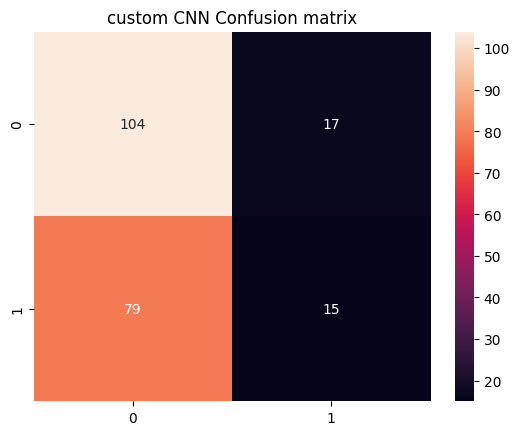

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
#predictions
y_pred = model_custom.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)
# true labels
y_true = test_data.classes
#classification report
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))
#confusion mtrix
cm = confusion_matrix(y_true, y_pred)
print("confusion matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("custom CNN Confusion matrix")
plt.show()

In [ ]:
from sklearn.matrics import f1_score
f1 = f1_score(y_true, y_pred)
print("f1_score:", f1)

# chart

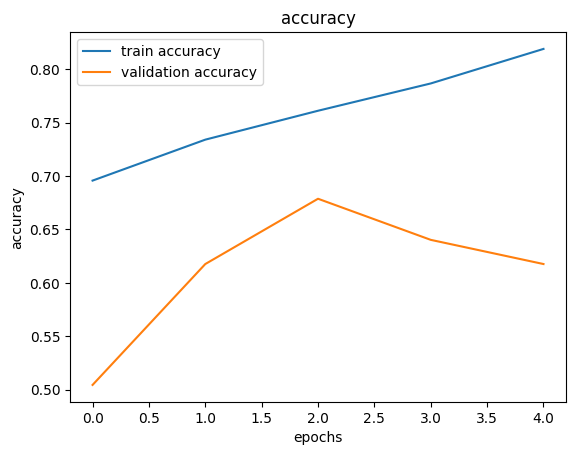

In [ ]:

#accuracy
plt.plot(history_custom.history['accuracy'], label='train accuracy')
plt.plot(history_custom.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

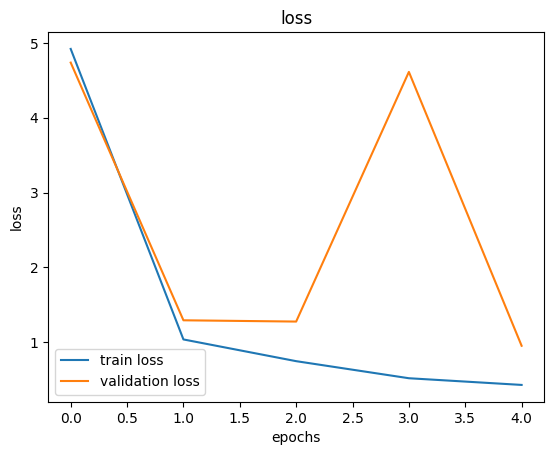

In [ ]:
#loss
plt.plot(history_custom.history['loss'], label='train loss')
plt.plot(history_custom.history['val_loss'], label='validation loss')
plt.legend()
plt.title("loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

training time

# model 2 -MobileNet

In [ ]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Flatten, Dense,Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
#load pre trained model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
#feeze layers
for layer in base_model.layers:
  layer.trainable = False
#add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)
model_mobilenet = Model(inputs=base_model.input, outputs=output)
model_mobilenet.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,193 (12.82 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

fine-tuning

In [ ]:
#unfreeze last few layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Model Train

training means feeding images---> model learns---->improves prediction

# MODEL TRAINING

1.Import Libraries

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,  ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

2.Compile model

In [ ]:
model_mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

3.Define Callbacks

In [ ]:
#earlystopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#Modelcheckpoint
checkpoint = ModelCheckpoint('moblienet_best_model.keras', monitor='val_loss',save_best_only=True)

4.Train Model

In [ ]:

import time
start = time.time()
history_mobilenet = model_mobilenet.fit(train_data, validation_data=valid_data,epochs=20, callbacks=[early_stop, checkpoint])
end = time.time()
time_mobilenet = end - start
print("MobileNet training time:", time_mobilenet)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.9455 - loss: 0.1419 - precision: 0.9423 - recall: 0.9415 - val_accuracy: 0.8484 - val_loss: 0.5597 - val_precision: 1.0000 - val_recall: 0.7022
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.9835 - loss: 0.0433 - precision: 0.9863 - recall: 0.9784 - val_accuracy: 0.9683 - val_loss: 0.0912 - val_precision: 0.9607 - val_recall: 0.9778
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.9936 - loss: 0.0202 - precision: 0.9928 - recall: 0.9936 - val_accuracy: 0.9706 - val_loss: 0.1101 - val_precision: 0.9569 - val_recall: 0.9867
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9899 - loss: 0.0285 - precision: 0.9888 - recall: 0.9896 - val_accuracy: 0.9344 - val_loss: 0.2425 - val_precision: 0.9495 - val_recall: 0.9200
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.9827 - loss: 0.0478 - precision: 0.9823 - recall: 0.9808 - val_accuracy: 0.9683 - val_loss: 0.1570 

here earlystopping is worked becouse from 1st epochs val_loss is 0.5597 and next is 0.0912 (improved) and after this val_loss geting incresed and cchangeing ,early stop applied after 3 ecpochs(patances =3) and it stops training
model was best at 2nd epoch

# MODEL EVALUATION

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
              precision    recall  f1-score   support

       birds       0.53      0.51      0.52       121
      drones       0.39      0.40      0.40        94

    accuracy                           0.47       215
   macro avg       0.46      0.46      0.46       215
weighted avg       0.47      0.47      0.47       215

confusion matrix:
 [[62 59]
 [56 38]]


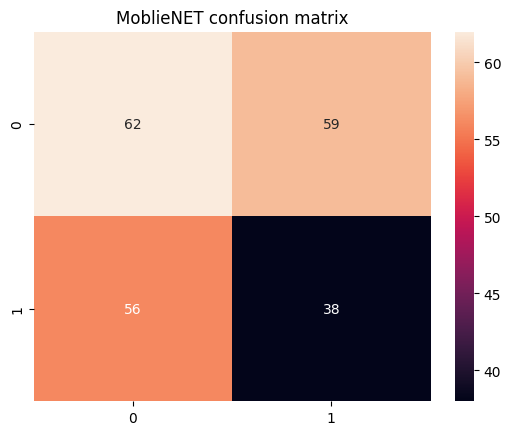

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
#predictions
y_pred = model_mobilenet.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)
# true labels
y_true = test_data.classes
#classification report
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))
#confusion mtrix
cm = confusion_matrix(y_true, y_pred)
print("confusion matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("MoblieNET confusion matrix")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print("f1_score:", f1)

f1_score: 0.39790575916230364


# GRAPHS

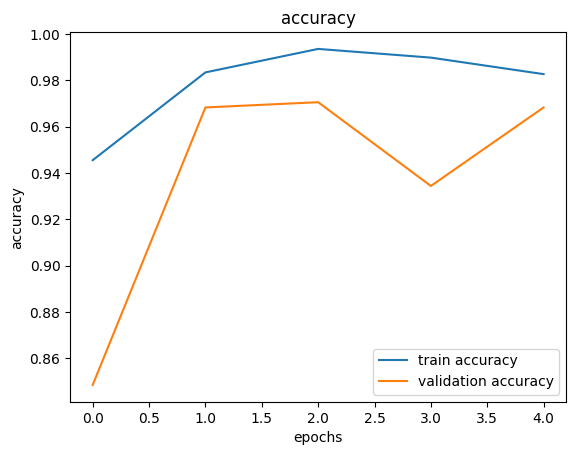

In [ ]:
#accuracy
plt.plot(history_mobilenet.history['accuracy'], label='train accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

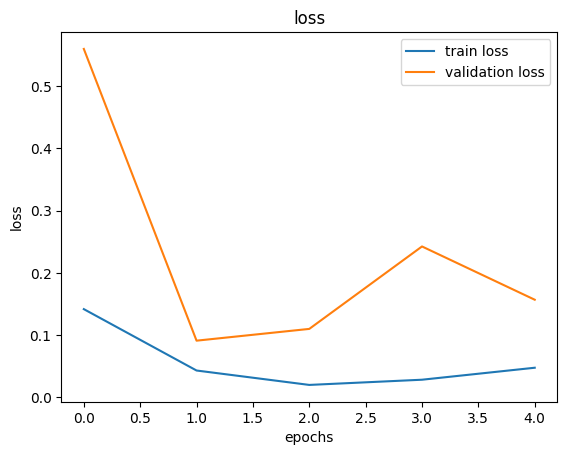

In [ ]:
#loss
plt.plot(history_mobilenet.history['loss'], label='train loss')
plt.plot(history_mobilenet.history['val_loss'], label='validation loss')
plt.legend()
plt.title("loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

training time

# Transfer Learing model 2(ResNet50)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
#load pretrained model
base_model = ResNet50(weights='imagenet',include_top=False, input_shape=(224,224,3))
#freeze layers
for layer in base_model.layers:
   layer.trainable = False
#add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)
model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

conv5_block3_out--->(none,7,7,2048)
* image is now very small :7*7
* but very deep :2048 features
global_average_pooling2d--->(none, 2048)
* it converted 7*7*2048 to 2048
* takes average of each feature map
* now it become a 1D vector
dense_6--->(none,128),pramas 262272
* reduced features from 2048 to 128
* learns patterns specific to dataset(and model learns the problem here)
dropout_3---->(none,128),params 0
* prevents overfitting
* normaly drops neurons
dense_7---->(none,1),params 129
*output =1 value(used for binary classification)
model summary
entire model size is 2,38,50,113
only 2,62,401 parameters are learning(they belong to dense,output layers)
* most of the model is pre tranined(frozen that is 2,35,87,712 parameters)

#MODEL TRAINING

1.Import Libraries

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,  ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

2.Compile Model

In [ ]:
model_resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

3.Define Callbacks

In [ ]:
#earlystopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#Modelcheckpoint

checkpoint = ModelCheckpoint('resnet_best_model.keras', monitor='val_loss',save_best_only=True)

4.Train Model

In [ ]:

import time
start = time.time()
history_resnet = model_resnet.fit(train_data, validation_data=valid_data,epochs=20, callbacks=[early_stop, checkpoint])
end = time.time()
time_resnet = end - start
print("ResNet50 training time:", time_resnet)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 671s 8s/step - accuracy: 0.6228 - loss: 0.6644 - precision: 0.6253 - recall: 0.4880 - val_accuracy: 0.6719 - val_loss: 0.6213 - val_precision: 0.7381 - val_recall: 0.5511
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 656s 8s/step - accuracy: 0.6424 - loss: 0.6316 - precision: 0.6693 - recall: 0.4688 - val_accuracy: 0.6629 - val_loss: 0.6062 - val_precision: 0.8333 - val_recall: 0.4222
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 0.6469 - loss: 0.6246 - precision: 0.6750 - recall: 0.4760 - val_accuracy: 0.6787 - val_loss: 0.5918 - val_precision: 0.7986 - val_recall: 0.4933
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 654s 8s/step - accuracy: 0.6476 - loss: 0.6106 - precision: 0.6765 - recall: 0.4760 - val_accuracy: 0.6742 - val_loss: 0.5882 - val_precision: 0.8649 - val_recall: 0.4267
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 657s 8s/step - accuracy: 0.6645 - loss: 0.5979 - precision: 0.6839 - recall: 0.5288 - val_accuracy: 0.5769 - val_loss: 0.6073 

# MODEL EVALUATION

7/7 ━━━━━━━━━━━━━━━━━━━━ 63s 7s/step
              precision    recall  f1-score   support

       birds       0.56      0.74      0.64       121
      drones       0.43      0.24      0.31        94

    accuracy                           0.53       215
   macro avg       0.49      0.49      0.47       215
weighted avg       0.50      0.53      0.50       215

confusion matrix:
 [[90 31]
 [71 23]]


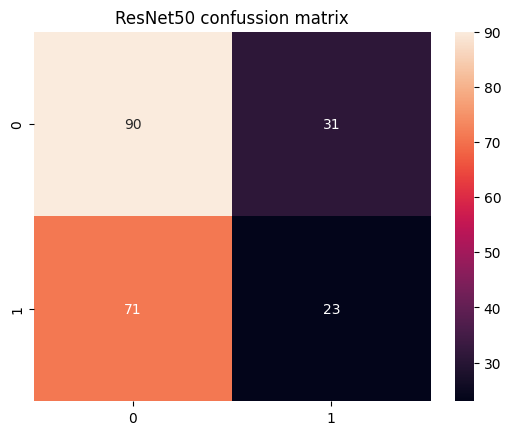

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
#predictions
y_pred = model_resnet.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)
# true labels
y_true = test_data.classes
#classification report
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))
#confusion mtrix
cm = confusion_matrix(y_true, y_pred)
print("confusion matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("ResNet50 confussion matrix")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print("f1_score:", f1)

f1_score: 0.3108108108108108


GRAPHS

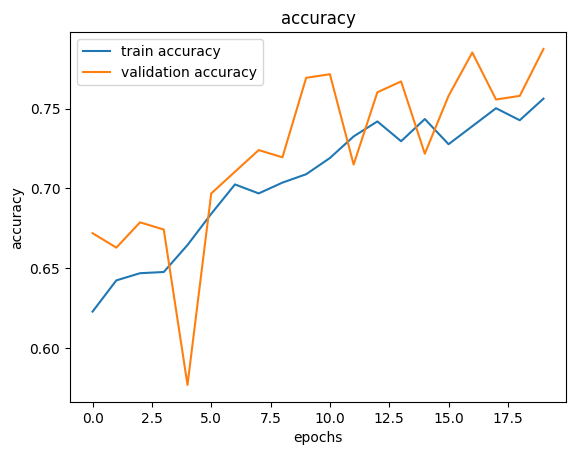

In [ ]:
#accuracy
plt.plot(history_resnet.history['accuracy'], label='train accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

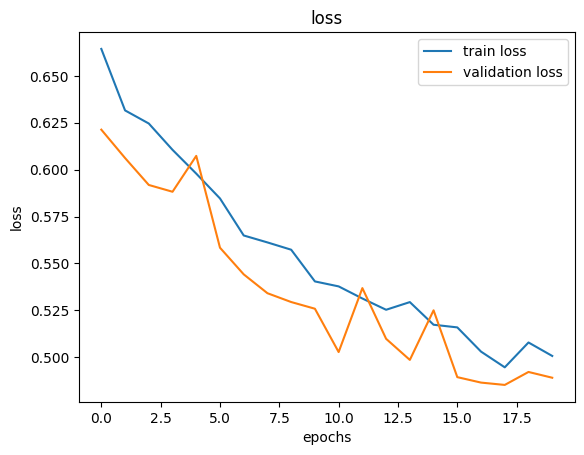

In [ ]:
#loss
plt.plot(history_resnet.history['loss'], label='train loss')
plt.plot(history_resnet.history['val_loss'], label='validation loss')
plt.legend()
plt.title("loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

training time

# EFFICIENTNETB0 MODEL

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

#load pretrained model

base_model = EfficientNetB0(weights='imagenet',include_top=False, input_shape=(224,224,3))

#freeze layers
for layer in base_model.layers:
   layer.trainable = False

#add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

#final model
model_effnet = Model(inputs=base_model.input, outputs=output)
model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# MODEL TRAINING

1.Import Libraries

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,  ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

2. Compile Model

In [ ]:
model_effnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

3.Define Callbacks

In [ ]:
#earlystopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
#Modelcheckpoint

checkpoint = ModelCheckpoint('effnet_best_model.keras', monitor='val_loss',save_best_only=True)

4.Train Model

In [ ]:
import time
start = time.time()
history_effnet = model_effnet.fit(train_data, validation_data=valid_data,epochs=10, callbacks=[early_stop, checkpoint])
end = time.time()
time_effnet = end - start
print("EfficientNetB0 training time:", time_effnet)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 280s 3s/step - accuracy: 0.4947 - loss: 0.7166 - precision: 0.4505 - recall: 0.3534 - val_accuracy: 0.4910 - val_loss: 0.6993 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.5244 - loss: 0.6931 - precision: 0.4308 - recall: 0.0449 - val_accuracy: 0.4910 - val_loss: 0.6962 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.5312 - loss: 0.6927 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.4910 - val_loss: 0.6948 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.5312 - loss: 0.6913 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.4910 - val_loss: 0.6951 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.5312 - loss: 0.6920 - precision: 0.5000 - recall: 0

early stop ia applied at epoch 6 val_loss is best at(0.6948 epoch3)
efficient training time is 1581.0469

# MODEL EVALUATION

7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step
              precision    recall  f1-score   support

       birds       0.56      1.00      0.72       121
      drones       0.00      0.00      0.00        94

    accuracy                           0.56       215
   macro avg       0.28      0.50      0.36       215
weighted avg       0.32      0.56      0.41       215

confusion matrix:
 [[121   0]
 [ 94   0]]


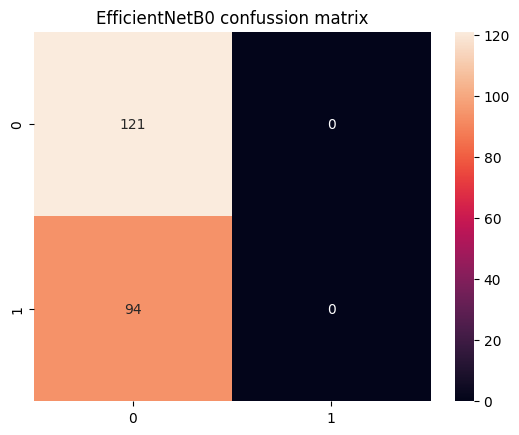

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
#predictions
y_pred = model_effnet.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)
# true labels
y_true = test_data.classes
#classification report
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))
#confusion mtrix
cm = confusion_matrix(y_true, y_pred)
print("confusion matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("EfficientNetB0 confussion matrix")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print("f1_score:", f1)

f1_score: 0.0


# **GRAPHS**



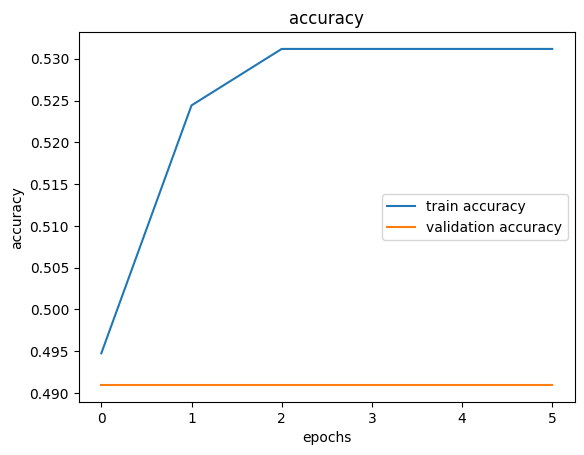

In [ ]:
#accuracy
plt.plot(history_effnet.history['accuracy'], label='train accuracy')
plt.plot(history_effnet.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

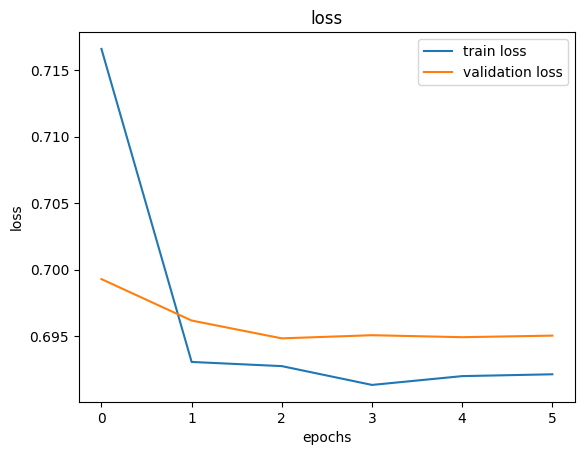

In [ ]:
#loss
plt.plot(history_effnet.history['loss'], label='train loss')
plt.plot(history_effnet.history['val_loss'], label='validation loss')
plt.legend()
plt.title("loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

training time

# **MODEL COMPARSION**

# *1. Compare Accuracy*

In [ ]:
accuracy_dict ={"Custom CNN":history_custom.history['val_accuracy'][-1], "MobileNet":history_mobilenet.history['val_accuracy'][-1], "ResNet50":history_resnet.history['val_accuracy'][-1], "EfficientNetB0":history_effnet.history['val_accuracy'][-1]}
print (accuracy_dict)

{'Custom CNN': 0.6176470518112183, 'MobileNet': 0.9683257937431335, 'ResNet50': 0.7873303294181824, 'EfficientNetB0': 0.49095022678375244}


# *2.Compare Training Time*

In [ ]:
time_dict = {"Custom CNN":time_cnn, "MobileNet":time_mobilenet, "ResNet50":time_resnet, "EfficientNetB0":time_effnet}
print(time_dict)

{'Custom CNN': 2698.858170032501, 'MobileNet': 1242.6221029758453, 'ResNet50': 13836.017511606216, 'EfficientNetB0': 1581.0469586849213}


# *3.Genralization Performance*

In [ ]:
def gereralization_gap(history):
  train_acc = history.history['accuracy'][-1]
  val_acc = history.history['val_accuracy'][-1]
  return train_acc - val_acc
gen_gap = {"Custom CNN":gereralization_gap(history_custom),
           "MobileNet":gereralization_gap(history_mobilenet),
           "ResNet50":gereralization_gap(history_resnet),
           "EfficientNetB0":gereralization_gap(history_effnet)}
print(gen_gap)

{'Custom CNN': 0.20128607749938965, 'MobileNet': 0.014393985271453857, 'ResNet50': -0.031131982803344727, 'EfficientNetB0': 0.04022932052612305}


# *4.Create Comparison Table*

In [ ]:
comparison_df = pd.DataFrame({
    "Accuracy": accuracy_dict,
    "Training Time": time_dict,
    "Generalization Gap": gen_gap
})
# The dictionary keys should now be consistent, so the groupby is no longer strictly necessary
# but can be kept for robustness if other sources of inconsistency might exist.
# For now, we will simply assign the DataFrame.
print(comparison_df)

                Accuracy  Training Time  Generalization Gap
Custom CNN      0.617647    2698.858170            0.201286
MobileNet       0.968326    1242.622103            0.014394
ResNet50        0.787330   13836.017512           -0.031132
EfficientNetB0  0.490950    1581.046959            0.040229


# *5.Visualization*

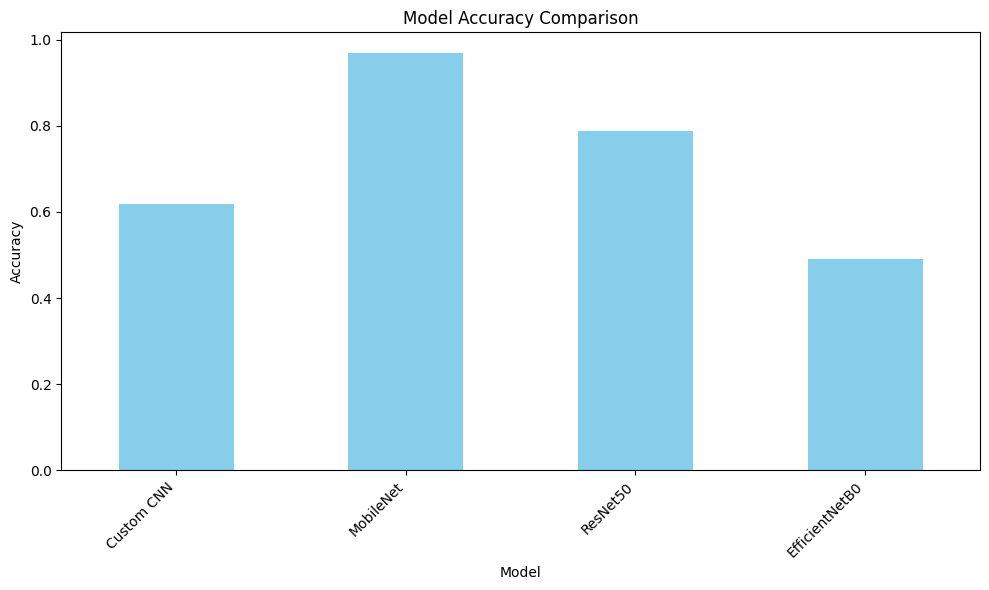

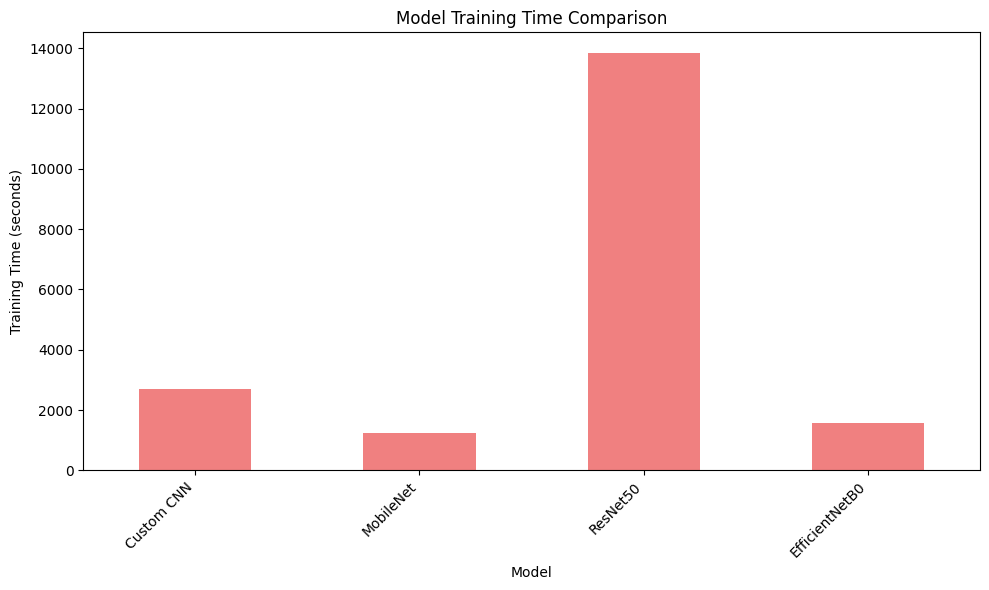

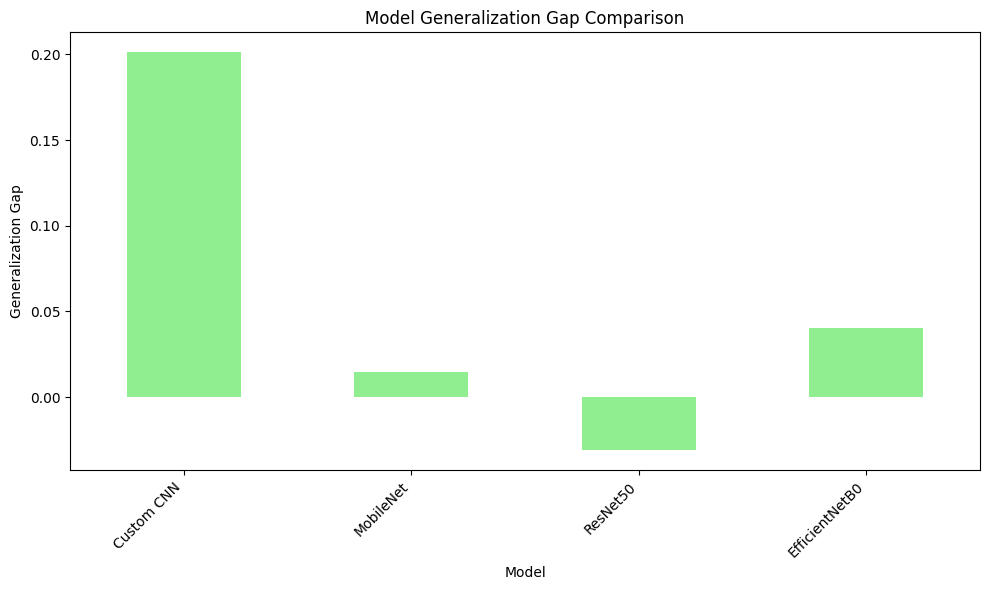

In [ ]:
# Plotting Accuracy
plt.figure(figsize=(10, 6))
comparison_df['Accuracy'].plot(kind='bar', color='skyblue')
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting Training Time
plt.figure(figsize=(10, 6))
comparison_df['Training Time'].plot(kind='bar', color='lightcoral')
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting Generalization Gap
plt.figure(figsize=(10, 6))
comparison_df['Generalization Gap'].plot(kind='bar', color='lightgreen')
plt.title("Model Generalization Gap Comparison")
plt.xlabel("Model")
plt.ylabel("Generalization Gap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# *6.Select Best Model.and why?*

Best Model: MobileNet

why because
* highest accuracy (0.9683, significantly outperforming others)
* showed excellent generalization with a minimal generalization gap (0.0144), indicating low overfitting.
* less trining time(1242 sec)
* provided a good balance between high performance and reasonable computational efficiency compared to ResNet50.

# Save Best Model

In [ ]:
model_mobilenet.save("Best_model.keras")

# Load Later in Streamlit

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("Best_model.keras")

### Loading the Model in Streamlit
To use this model in a Streamlit application, ensure you have `tensorflow` installed in your Streamlit environment and use the following code structure:

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('Best_model.keras')

def predict(image_path):
    # Streamlit would pass an uploaded file here
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    return "Drone" if prediction[0][0] > 0.5 else "Bird"

# STREAMILT DEPLOYMENT CODE

1.INSTALL STREAMILT

In [ ]:
!pip install -q streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Set page title
st.title('Drone vs Bird Classifier')

# Load the best model
@st.cache_resource
def load_my_model():
    return tf.keras.models.load_model('Best_model.keras')

model = load_my_model()

# File uploader
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("Classifying...")

    # Preprocess the image
    img = image.resize((224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    result = "Drone" if prediction[0][0] > 0.5 else "Bird"
    confidence = prediction[0][0] if result == "Drone" else 1 - prediction[0][0]

    st.header(f"Result: {result}")
    st.write(f"Confidence: {confidence:.2%}")